In [ ]:
pip install snntorch torch torchvision numpy

In [ ]:
pip install matplotlib ipykernel pillow

In [2]:
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate
import snntorch.functional as SF
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import os
import matplotlib.pyplot as plt

In [4]:
# Create weights directory if it doesn't exist
os.makedirs("weights", exist_ok=True)

# --- 1. SETTINGS ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
num_epochs = 10
beta = 0.5
threshold = 1.0

# --- 2. DATA LOADING ---
transform = transforms.Compose([
    transforms.Resize((28, 28)), 
    transforms.ToTensor(), 
    transforms.Normalize((0,), (1,))
])
mnist_train = datasets.MNIST('data', train=True, download=True, transform=transform)
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)

# --- 3. THE SNN ARCHITECTURE ---
class HardwareSNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.lif1 = snn.Leaky(beta=beta, threshold=threshold, spike_grad=surrogate.fast_sigmoid())
        self.fc2 = nn.Linear(128, 10)
        self.lif2 = snn.Leaky(beta=beta, threshold=threshold, spike_grad=surrogate.fast_sigmoid())

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spk2_rec = []

        # Flatten input
        x = x.view(x.size(0), -1) 

        for step in range(25):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)

        return torch.stack(spk2_rec, dim=0)

# --- 4. TRAINING LOOP ---
net = HardwareSNN().to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=5e-4)
loss_fn = SF.ce_count_loss()

best_loss = float('inf')  # Initialize with infinity
print(f"Training started on device: {device}")

for epoch in range(num_epochs):
    epoch_loss = 0
    net.train()
    
    for i, (data, targets) in enumerate(train_loader):
        if data.size(0) != batch_size: continue
        data, targets = data.to(device), targets.to(device)

        spk_rec = net(data)
        loss_val = loss_fn(spk_rec, targets)

        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()
        
        epoch_loss += loss_val.item()

    # Calculate average loss for the epoch
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1} complete. Avg Loss: {avg_loss:.4f}")

    # SAVE BEST LOGIC
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(net.state_dict(), "weights/best_model.pt")
        print(f"--> New best weights found and saved! (Loss: {best_loss:.4f})")

# --- . EXPORT BEST WEIGHTS  ---
net.load_state_dict(torch.load("weights/best_model.pt"))
net.eval()

# Extracting weights from the Linear layers
w_ih = net.fc1.weight.detach().cpu().numpy() # 128x784
w_ho = net.fc2.weight.detach().cpu().numpy() # 10x128

# Quantize to 8-bit integers (-128 to 127)
def to_hw(w):
    # We use a robust max to avoid scaling issues from single outliers
    scale = 127 / (np.max(np.abs(w)) + 1e-9)
    return (w * scale).astype(np.int8)

np.save("weights/weights_ih.npy", to_hw(w_ih))
np.save("weights/weights_ho.npy", to_hw(w_ho))
print("Quantized weights saved as .npy! Ready for COE conversion.")

Training started on device: cuda
Epoch 1 complete. Avg Loss: 0.4993
--> New best weights found and saved! (Loss: 0.4993)
Epoch 2 complete. Avg Loss: 0.1988
--> New best weights found and saved! (Loss: 0.1988)
Epoch 3 complete. Avg Loss: 0.1512
--> New best weights found and saved! (Loss: 0.1512)
Epoch 4 complete. Avg Loss: 0.1254
--> New best weights found and saved! (Loss: 0.1254)
Epoch 5 complete. Avg Loss: 0.1064
--> New best weights found and saved! (Loss: 0.1064)
Epoch 6 complete. Avg Loss: 0.0945
--> New best weights found and saved! (Loss: 0.0945)
Epoch 7 complete. Avg Loss: 0.0833
--> New best weights found and saved! (Loss: 0.0833)
Epoch 8 complete. Avg Loss: 0.0755
--> New best weights found and saved! (Loss: 0.0755)
Epoch 9 complete. Avg Loss: 0.0672
--> New best weights found and saved! (Loss: 0.0672)
Epoch 10 complete. Avg Loss: 0.0623
--> New best weights found and saved! (Loss: 0.0623)

Reloading best weights for VHDL export...
Quantized weights saved as .npy! Ready for 

In [24]:
os.makedirs("binaries", exist_ok=True)

# QUANTIZATION FUNCTION
def to_hw(w):
    # Scale to fit into 8-bit signed integer (-128 to 127)
    scale = 127 / (np.max(np.abs(w)) + 1e-9)
    return (w * scale).astype(np.int8), scale

# TRANSPOSE AND QUANTIZE
w_ih_fixed, scale_ih = to_hw(w_ih.T) # Now (784, 128)
w_ho_fixed, scale_ho = to_hw(w_ho.T) # Now (128, 10)

# SAVE TO BINARY
w_ih_fixed.tofile("binaries/weights_ih_transposed.bin")
w_ho_fixed.tofile("binaries/weights_ho_transposed.bin")

# PRINT DIMENSIONS AND BRAM CONFIG
print("="*40)
print("SNN HARDWARE EXPORT REPORT")
print("="*40)
print(f"Layer 1 (Input -> Hidden):")
print(f"  - Original Shape:  {w_ih.shape}")
print(f"  - Hardware Shape:  {w_ih_fixed.shape} (Grouped by Pixel)")
print(f"  - Total Elements:  {w_ih_fixed.size}")
print(f"  - Scale Factor:    {scale_ih:.4f}")
print("-" * 40)
print(f"Layer 2 (Hidden -> Output):")
print(f"  - Original Shape:  {w_ho.shape}")
print(f"  - Hardware Shape:  {w_ho_fixed.shape} (Grouped by Hidden Neuron)")
print(f"  - Total Elements:  {w_ho_fixed.size}")
print(f"  - Scale Factor:    {scale_ho:.4f}")
print("="*40)
print("Files saved: weights_ih_transposed.bin, weights_ho_transposed.bin")

SNN HARDWARE EXPORT REPORT
Layer 1 (Input -> Hidden):
  - Original Shape:  (128, 784)
  - Hardware Shape:  (784, 128) (Grouped by Pixel)
  - Total Elements:  100352
  - Scale Factor:    394.0491
----------------------------------------
Layer 2 (Hidden -> Output):
  - Original Shape:  (10, 128)
  - Hardware Shape:  (128, 10) (Grouped by Hidden Neuron)
  - Total Elements:  1280
  - Scale Factor:    430.6157
Files saved: weights_ih_transposed.bin, weights_ho_transposed.bin


IMAGE EXPORT REPORT
Target Label:  9
Dimensions:    (28, 28)
Flat Size:     784 bytes
Saved as:      binaries/test_image_label_9.bin


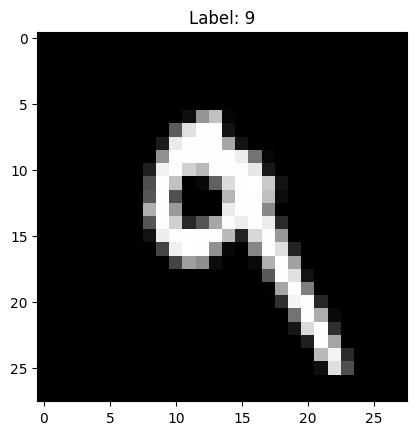

In [25]:
mnist_test = datasets.MNIST('data', train=False, download=True)

# SELECT IMAGE
image_index = 7
img, label = mnist_test[image_index]

img_np = np.array(img).astype(np.uint8)
img_flat = img_np.flatten()

# EXPORT IMAGE AS BIN
filename = f"binaries/test_image_label_{label}.bin"
img_flat.tofile(filename)

# REPORT
print("="*40)
print("IMAGE EXPORT REPORT")
print("="*40)
print(f"Target Label:  {label}")
print(f"Dimensions:    {img_np.shape}")
print(f"Flat Size:     {img_flat.size} bytes")
print(f"Saved as:      {filename}")
print("="*40)


# PLOT IMAGE
plt.imshow(img_np, cmap='gray')
plt.title(f"Label: {label}")
plt.show()

In [50]:

# LOAD WEIGHTS
w_ih = np.load("weights/weights_ih.npy")
w_ho = np.load("weights/weights_ho.npy")
mnist_test = datasets.MNIST('data', train=False, download=True, transform=transforms.ToTensor())

def test_hardware_model(image_data, w_ih, w_ho):
    vmem_hidden = np.zeros(128, dtype=np.int16)
    vmem_output = np.zeros(10, dtype=np.int16)
    spike_counts = np.zeros(10, dtype=np.int16)

    THRESHOLD = 175
    TIME_STEPS = 16
    SCALE_FACTOR = 1.0

    for t in range(TIME_STEPS):
        # --- TRUE RATE ENCODING ---
        input_spikes = (image_data / 255.0) > np.random.rand(784)

        for i, spk in enumerate(input_spikes):
            if spk:
                vmem_hidden += (w_ih[:, i] * SCALE_FACTOR).astype(np.int16)

        # --- HIDDEN LAYER ---
        hidden_spikes = np.zeros(128, dtype=np.int8)
        for j in range(128):
            vmem_hidden[j] -= (vmem_hidden[j] >> 1) # Leak
            if vmem_hidden[j] >= THRESHOLD:
                hidden_spikes[j] = 1
                vmem_hidden[j] = 0 # Reset# 1. LOAD WEIGHTS

        # --- OUTPUT LAYER ---
        for j, spk in enumerate(hidden_spikes):
            if spk:
                vmem_output += (w_ho[:, j] * SCALE_FACTOR).astype(np.int16)

        for k in range(10):
            vmem_output[k] -= (vmem_output[k] >> 1) # Leak
            if vmem_output[k] >= THRESHOLD:
                spike_counts[k] += 1
                vmem_output[k] = 0

    return np.argmax(spike_counts), spike_counts

# Run for TOTAL_IMAGES images...
TOTAL_IMAGES = 200
correct = 0
for idx in range(TOTAL_IMAGES):
    img, label = mnist_test[idx]
    pixels = (img.view(-1).numpy() * 255).astype(np.uint8)
    pred, counts = test_hardware_model(pixels, w_ih, w_ho)
    if pred == label and np.sum(counts) > 0: correct += 1
    print(f"Img {idx} | Label: {label} | Pred: {pred} | Counts: {counts}")

print(f"\nFinal Accuracy: {(correct/TOTAL_IMAGES)*100:.2f}%")

Img 0 | Label: 7 | Pred: 7 | Counts: [ 0  0  1  1  0  0  0 12  0  1]
Img 1 | Label: 2 | Pred: 2 | Counts: [ 0  0 11  0  0  0  0  0  0  0]
Img 2 | Label: 1 | Pred: 1 | Counts: [0 9 0 0 0 0 0 0 0 0]
Img 3 | Label: 0 | Pred: 0 | Counts: [10  0  0  0  0  0  0  0  0  0]
Img 4 | Label: 4 | Pred: 4 | Counts: [0 0 0 0 8 0 0 0 0 3]
Img 5 | Label: 1 | Pred: 1 | Counts: [0 8 0 0 0 0 0 3 0 0]
Img 6 | Label: 4 | Pred: 4 | Counts: [0 0 0 0 7 0 0 0 0 0]
Img 7 | Label: 9 | Pred: 9 | Counts: [0 0 0 0 0 0 0 0 0 8]
Img 8 | Label: 5 | Pred: 6 | Counts: [0 0 0 0 0 0 4 0 0 0]
Img 9 | Label: 9 | Pred: 9 | Counts: [0 0 0 0 0 0 0 5 0 7]
Img 10 | Label: 0 | Pred: 0 | Counts: [7 0 0 0 0 0 0 0 0 0]
Img 11 | Label: 6 | Pred: 6 | Counts: [3 0 0 0 0 0 6 0 0 0]
Img 12 | Label: 9 | Pred: 9 | Counts: [0 0 0 0 0 0 0 0 0 8]
Img 13 | Label: 0 | Pred: 0 | Counts: [13  0  0  0  0  0  0  5  0  2]
Img 14 | Label: 1 | Pred: 1 | Counts: [ 0 12  0  0  0  0  0  0  0  0]
Img 15 | Label: 5 | Pred: 5 | Counts: [0 0 0 1 0 9 0 0 0 0]
